In [3]:
!pip install torch==2.10.0
!pip install numpy==2.4.3
!pip install torchvision==0.25.0
!pip install scikit-learn==1.8.0

In [22]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.functional as F
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import ResNet18_Weights

from google.colab import files
import os
import matplotlib.pyplot as plt
from PIL import Image

import numpy as np
import random
from sklearn.model_selection import train_test_split

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

## **Loading the dataset and splitting**

In [ ]:

if not os.path.exists("kaggle.json"):
    files.upload()

# Step 2: Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 3: Download the Pokemon dataset
!kaggle datasets download -d lantian773030/pokemonclassification

# Step 4: Unzip it
!unzip pokemonclassification.zip -d /content/pokemon_data

# Check what's inside
!ls /content/pokemon_data

In [4]:
dataset_dir = 'pokemon_data/PokemonData/'

image_paths = []
labels = []

unique_labels = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])
label_to_idx = {name: i for i, name in enumerate(unique_labels)}
idx_to_label = {i: name for name, i in label_to_idx.items()}

num_classes = len(unique_labels)

for label in unique_labels:
    label_dir = os.path.join(dataset_dir, label)
    for image_file in os.listdir(label_dir):

        if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(label_dir, image_file))
            labels.append(label_to_idx[label])


print(f"The number of classes is: {num_classes}")
print(f"The number of images is: {len(image_paths)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

The number of classes is: 150
The number of images is: 6820
Using device: cuda


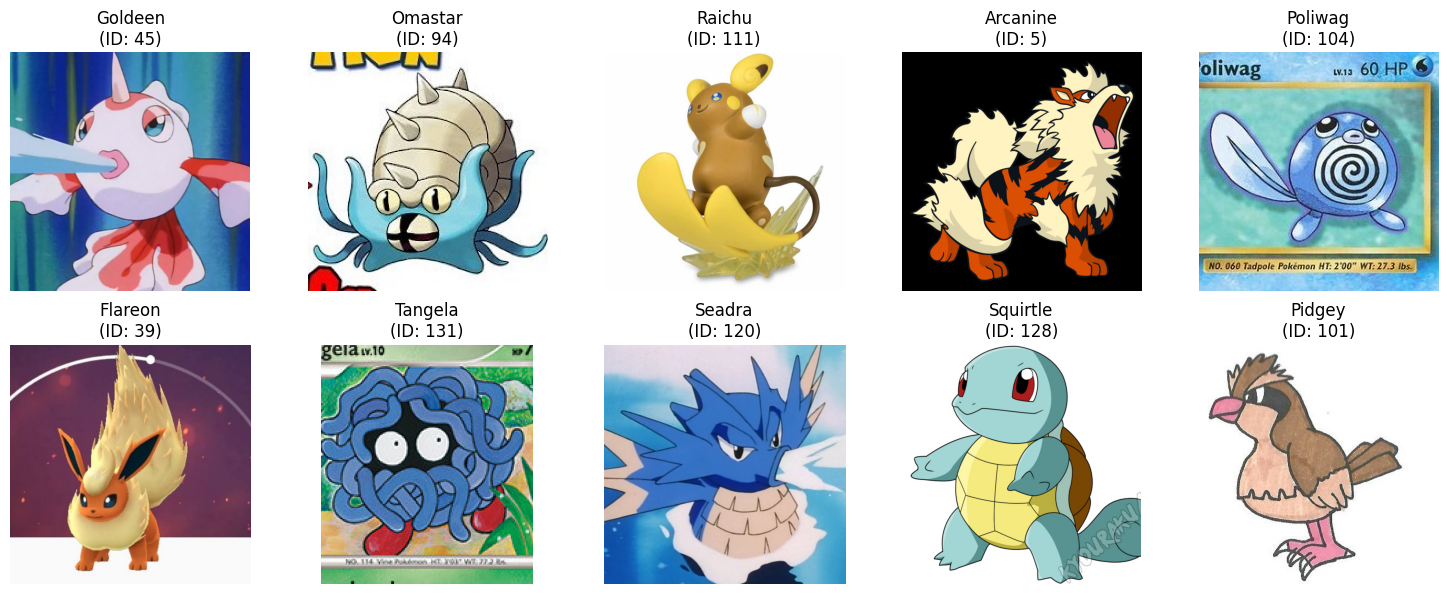

In [29]:
def plot_random_pokemon(image_paths, labels, idx_to_label, n=10):
    plt.figure(figsize=(15, 6))

    indices = random.sample(range(len(image_paths)), n)

    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)

        img = Image.open(image_paths[idx]).convert("RGB")
        plt.imshow(img)

        label_name = idx_to_label[labels[idx]]
        plt.title(f"{label_name}\n(ID: {labels[idx]})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_random_pokemon(image_paths, labels, idx_to_label)

In [5]:
train_paths, test_paths, train_labels, test_labels = train_test_split(image_paths, labels, test_size = 0.1, stratify = labels, random_state = 42)
train_paths, val_paths, train_labels, val_labels = train_test_split(train_paths, train_labels, test_size = 0.2, stratify= train_labels, random_state= 42)

print(f"Train: {len(train_paths)}")
print(f"Validation: {len(val_paths)}")
print(f"Test: {len(test_paths)}")

Train: 4910
Validation: 1228
Test: 682


In [6]:
class PokemonDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, torch.tensor(label).long()

## **Training function**

In [7]:
def train_one_epoch(model, train_loader, optimizer, criterion):
    model.train()

    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).long().view(-1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def eval_model(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).long().view(-1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy



In [8]:
def plot_results(history):
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='#e74c3c', lw=2)
    plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='#3498db', lw=2)
    plt.title('Training & Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_accuracy'], label='Val Accuracy', color='#2ecc71', lw=2)
    plt.title('Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## **Training a Small MLP**

In [13]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = PokemonDataset(train_paths, train_labels, transform=transform)
val_dataset = PokemonDataset(val_paths, val_labels, transform=transform)
test_dataset = PokemonDataset(test_paths, test_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_size = 128 * 128 * 3

print(f"Input size: {input_size}")

Input size: 49152


In [10]:
model = nn.Sequential(
    nn.Linear(input_size, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
model.to(device)


Sequential(
  (0): Linear(in_features=49152, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=150, bias=True)
)

Epoch: 01 | Train Loss: 5.0829 | Val Loss: 5.0103 | Val Acc: 0.90%
Epoch: 10 | Train Loss: 4.6002 | Val Loss: 4.6574 | Val Acc: 2.04%
Epoch: 20 | Train Loss: 3.8922 | Val Loss: 4.1441 | Val Acc: 7.17%
Epoch: 30 | Train Loss: 3.2659 | Val Loss: 4.4251 | Val Acc: 8.39%
Epoch: 40 | Train Loss: 2.8097 | Val Loss: 5.0576 | Val Acc: 11.48%
Epoch: 50 | Train Loss: 2.4369 | Val Loss: 5.5901 | Val Acc: 12.21%


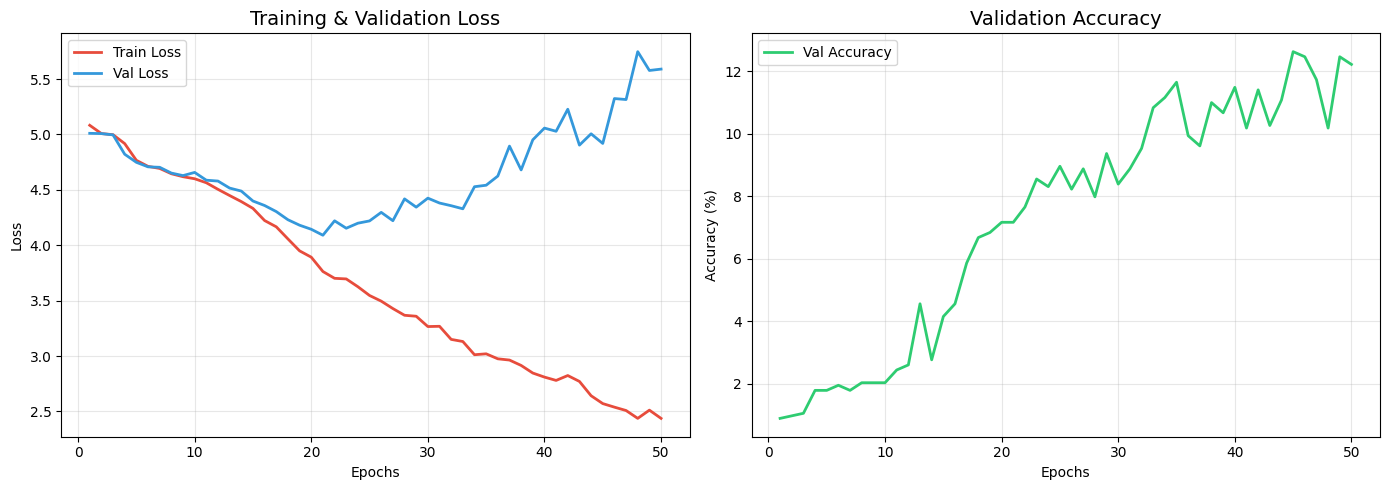

In [11]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': []
}

epochs = 50

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_accuracy = eval_model(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")


plot_results(history)


In [14]:
test_loss, test_accuracy = eval_model(model, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 6.0604 | Test Accuracy: 12.61%


## **Train a complex CNN**

In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = PokemonDataset(train_paths, train_labels, transform=transform)
val_dataset = PokemonDataset(val_paths, val_labels, transform=transform)
test_dataset = PokemonDataset(test_paths, test_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_size = 224

print(f"Input size: {input_size}×{input_size}×{3}")

Input size: 224×224×3


KeyError: 'std'

In [21]:
model = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),


    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(256, 512, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(100352, 2048),
    nn.ReLU(),
    nn.Linear(2048, len(unique_labels))
)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
model.to(device)



Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=100352, out_features=2048, bias=True)
  (14): ReLU()
  (15): Linear(in_features=2048, out_features=150, bias=True)
)

In [17]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': []
}

epochs = 50

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_accuracy = eval_model(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")


plot_results(history)

Epoch: 01 | Train Loss: 5.0569 | Val Loss: 5.0087 | Val Acc: 0.90%
Epoch: 10 | Train Loss: 5.0025 | Val Loss: 4.9998 | Val Acc: 0.98%
Epoch: 20 | Train Loss: 5.0017 | Val Loss: 4.9997 | Val Acc: 0.98%
Epoch: 30 | Train Loss: 5.0016 | Val Loss: 4.9998 | Val Acc: 0.98%


KeyboardInterrupt: 

In [ ]:
test_loss, test_accuracy = eval_model(model, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

Even with this big CNN (relatively), training takes sooo long and no improvements, so we will go for the transfer learning

## **Training Resnet18 (only the FC layer)**

In [28]:
weights = ResNet18_Weights.DEFAULT
inference_transform = weights.transforms()

transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = PokemonDataset(train_paths, train_labels, transform=transform_resnet)
val_dataset = PokemonDataset(val_paths, val_labels, transform=transform_resnet)
test_dataset = PokemonDataset(test_paths, test_labels, transform=transform_resnet)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_size = 224
print(f"Input size: {input_size}×{input_size}×3")

Input size: 224×224×3


In [29]:
model = models.resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Epoch: 01 | Train Loss: 4.0592 | Val Loss: 2.8647 | Val Acc: 47.07%
Epoch: 10 | Train Loss: 0.2288 | Val Loss: 0.8752 | Val Acc: 78.83%
Epoch: 20 | Train Loss: 0.0704 | Val Loss: 0.7850 | Val Acc: 79.80%
Epoch: 30 | Train Loss: 0.0314 | Val Loss: 0.7584 | Val Acc: 80.21%
Epoch: 40 | Train Loss: 0.0233 | Val Loss: 0.7962 | Val Acc: 79.72%
Epoch: 50 | Train Loss: 0.0184 | Val Loss: 0.8416 | Val Acc: 79.23%


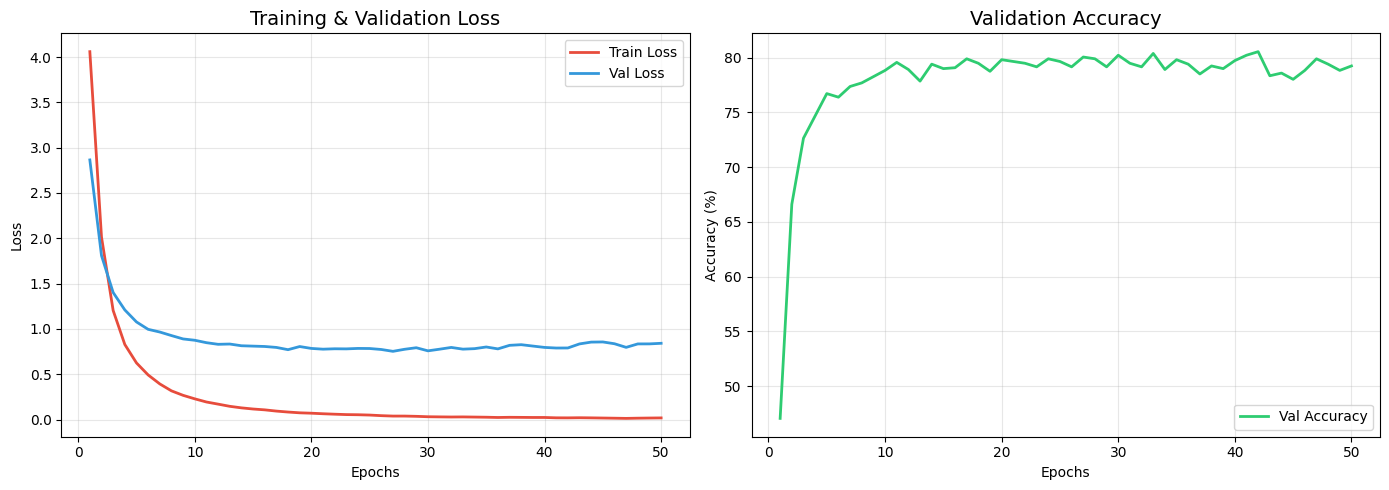

In [30]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': []
}

epochs = 50

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_accuracy = eval_model(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")


plot_results(history)

In [31]:
test_loss, test_accuracy = eval_model(model, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.6739 | Test Accuracy: 81.09%


### **Some kernel plotting**

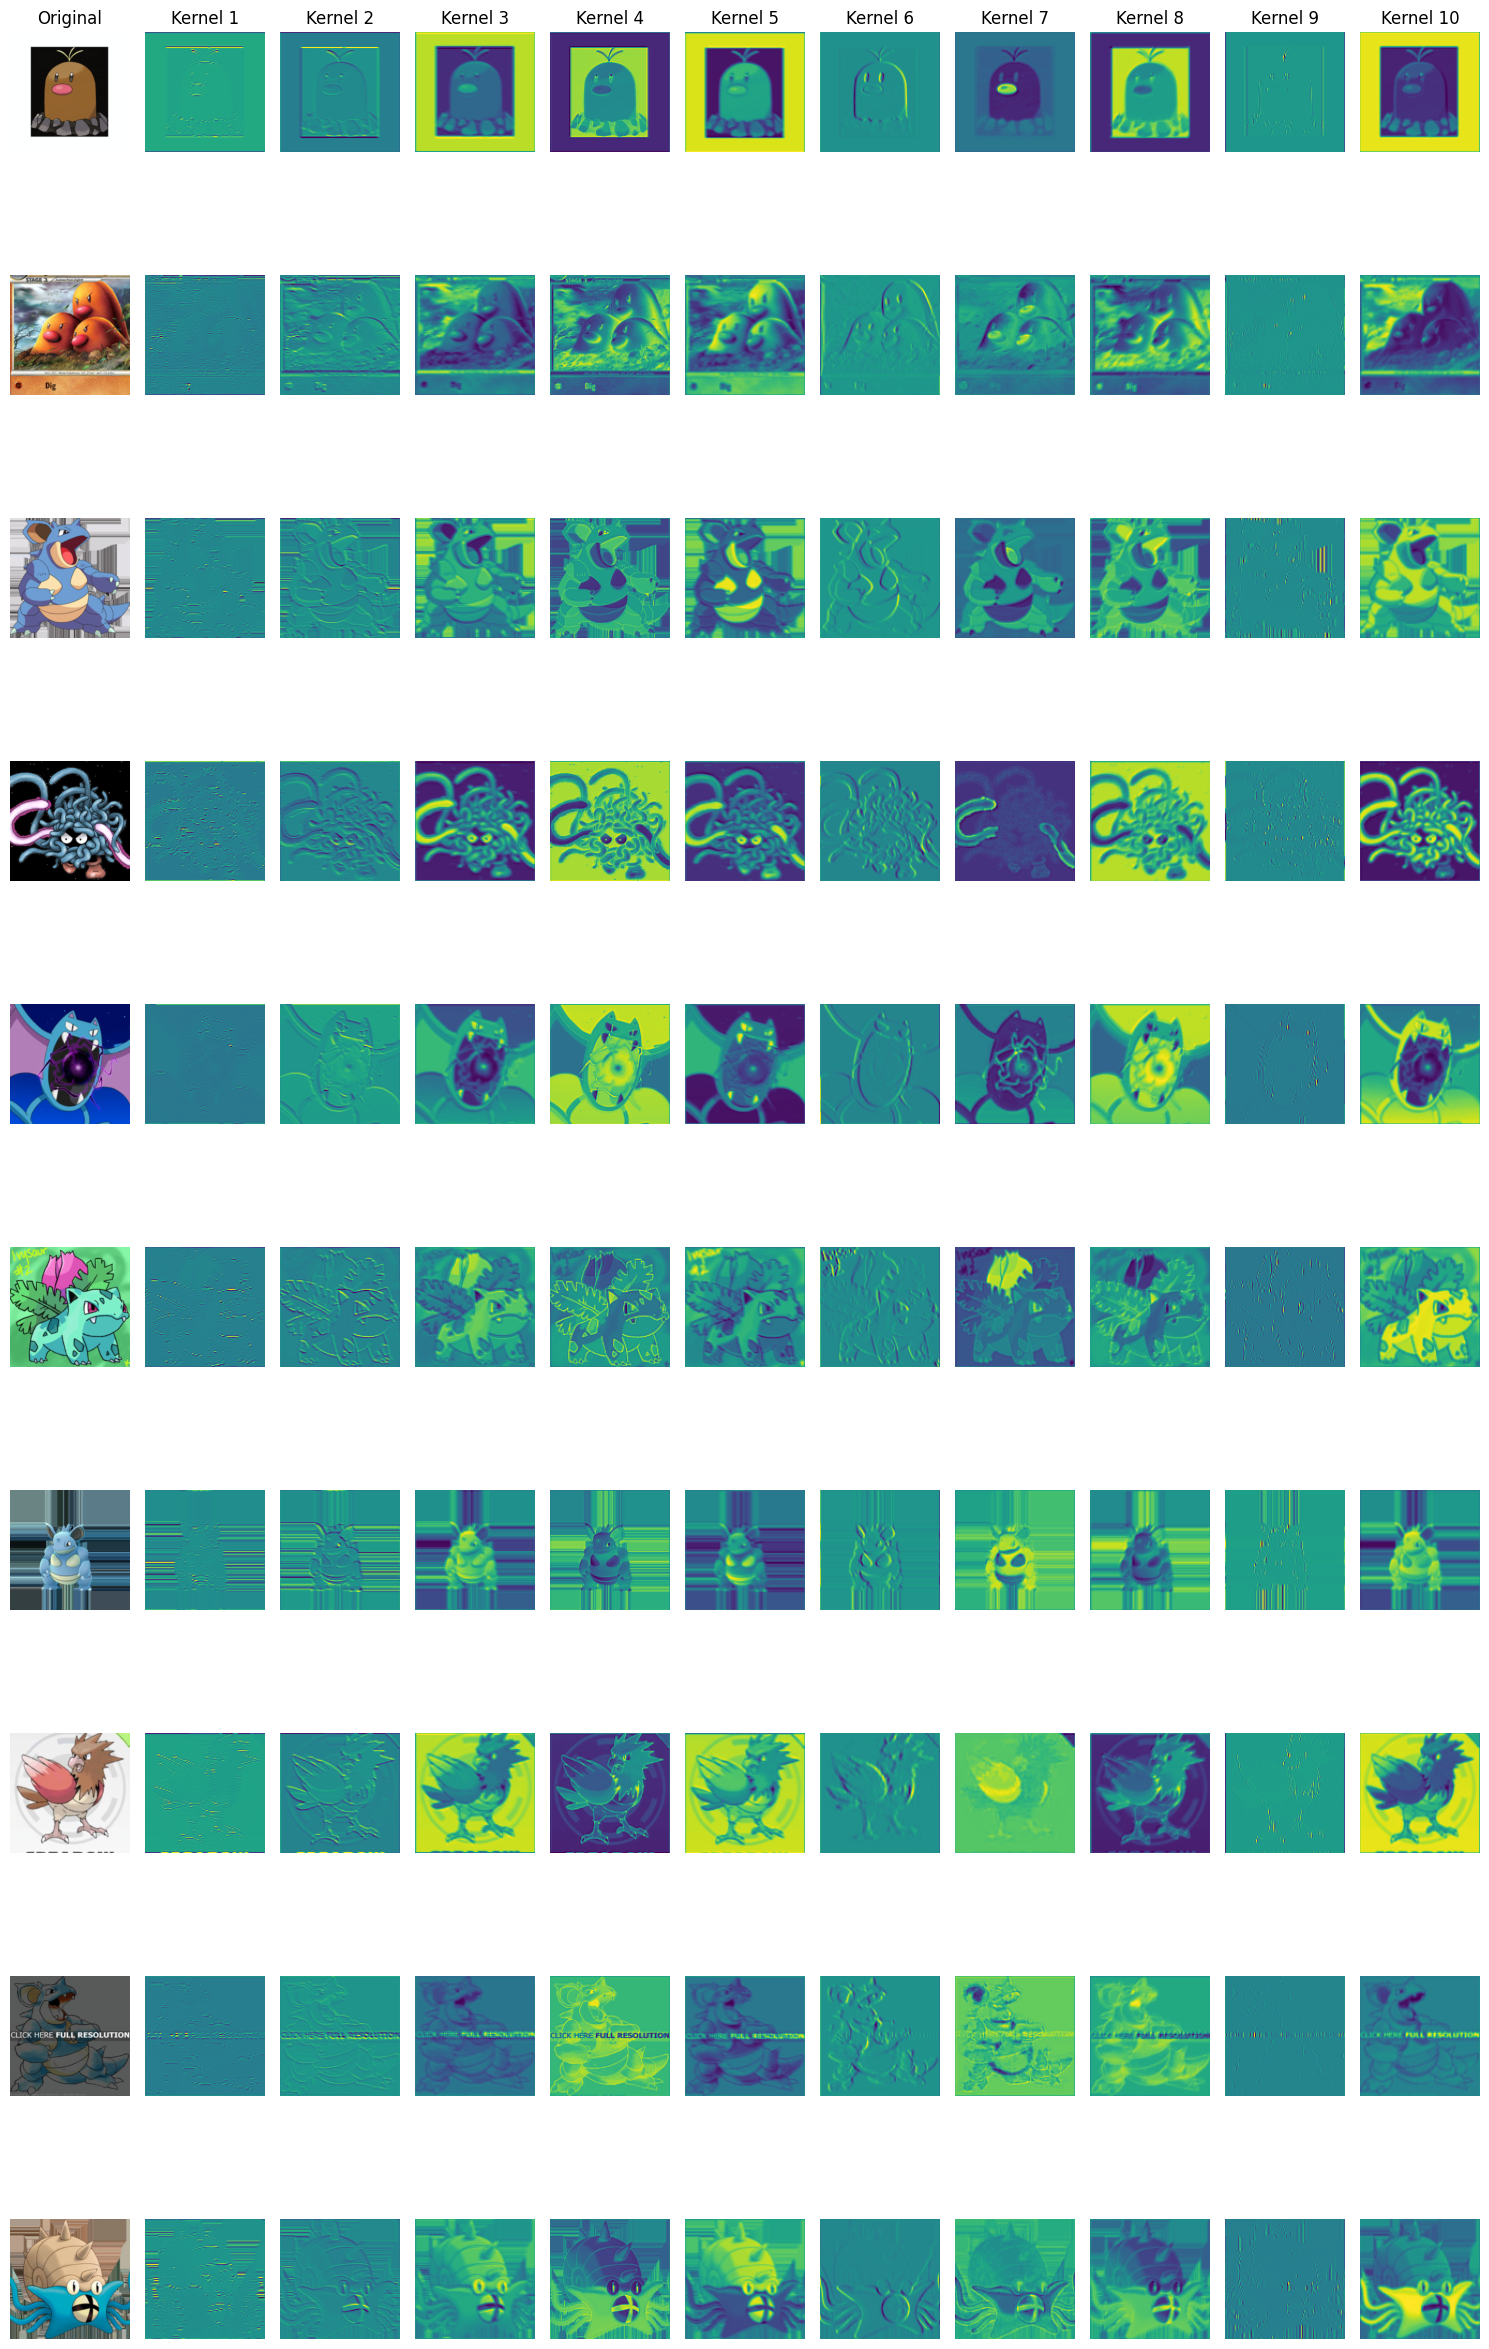

In [35]:
def visualize_multi_image_kernels(model, loader, device, num_images=5, num_kernels=5):
    """
    Visualizes the feature maps of multiple images using the same set of kernels.
    """
    model.eval()


    images, labels = next(iter(loader))
    img_batch = images[:num_images].to(device)


    with torch.no_grad():
        feature_maps = model.conv1(img_batch)

    fig, axes = plt.subplots(num_images, num_kernels + 1, figsize=(15, num_images * 2.5))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(num_images):
        ax_orig = axes[i, 0]
        original_img = images[i].permute(1, 2, 0).cpu().numpy()

        original_img = (original_img * std) + mean
        ax_orig.imshow(original_img.clip(0, 1))
        if i == 0:
            ax_orig.set_title("Original", fontsize=12)
        ax_orig.axis('off')

        for j in range(num_kernels):
            ax_fmap = axes[i, j + 1]
            f_map = feature_maps[i, j].cpu().numpy()

            ax_fmap.imshow(f_map, cmap='viridis')
            if i == 0:
                ax_fmap.set_title(f"Kernel {j+1}", fontsize=12)
            ax_fmap.axis('off')

    plt.tight_layout()
    plt.show()


visualize_multi_image_kernels(model, test_loader, device, num_images= 10, num_kernels=10)